In [1]:
# importar bibliotecas
from google.cloud import bigquery
from google.oauth2 import service_account
import pandas as pd
import seaborn as sns

In [2]:
# Realizar conexão com o GCP
credentials = service_account.Credentials.from_service_account_file("..\..\keys\ml-na-saude-ed1fc3c1a83e.json")
client = bigquery.Client(credentials=credentials, project=credentials.project_id)
consulta_sql = """SELECT * FROM `ml-na-saude.yll_por_obito.yll_por_obito`"""
df = client.query(consulta_sql).to_dataframe()

In [3]:
# Apresentar os primeiros dados
df.head()

,ano_obito,quad_obito,dt_obito,dt_nasc,idade,yll,cid10,cd_mun_res,populacao,__index_level_0__
0,2010,2,2010-06-27 00:00:00+00:00,2010-03-28 00:00:00+00:00,0.25,89.55,E126,270642,10511.0,879
1,2010,1,2010-04-10 00:00:00+00:00,1993-07-10 00:00:00+00:00,16.75,72.60,N10,270915,42144.0,1862
2,2010,3,2010-09-20 00:00:00+00:00,2000-04-09 00:00:00+00:00,10.45,77.58,E41,270320,23854.0,2763
3,2010,1,2010-02-10 00:00:00+00:00,2008-12-27 00:00:00+00:00,1.12,89.07,E40,130150,16662.0,3933
4,2010,2,2010-05-10 00:00:00+00:00,2008-12-29 00:00:00+00:00,1.36,89.07,J42,130340,104059.0,4019


In [4]:
# Apresentar o total de dados e colunas
df.shape

(1755025, 10)

In [5]:
# Verificar se existem dados nulos
df.isna().sum()

ano_obito              0
quad_obito             0
dt_obito               0
dt_nasc                0
idade                  0
yll                    0
cid10                  0
cd_mun_res             0
populacao            990
__index_level_0__      0
dtype: int64

In [6]:
# Analisar os dados nulos
mask = df['populacao'].isnull()
dados_nulos = df[mask]
dados_nulos.head()

,ano_obito,quad_obito,dt_obito,dt_nasc,idade,yll,cid10,cd_mun_res,populacao,__index_level_0__
96,2010,1,2010-03-15 00:00:00+00:00,1984-02-17 00:00:00+00:00,26.07,62.66,A153,330000,NaN,96208
1381,2018,1,2018-02-19 00:00:00+00:00,1989-04-20 00:00:00+00:00,28.84,62.66,A150,350000,NaN,1534919
1559,2019,3,2019-12-24 00:00:00+00:00,1994-12-29 00:00:00+00:00,24.99,67.62,A169,330000,NaN,1724290
1612,2010,3,2010-10-29 00:00:00+00:00,1954-05-12 00:00:00+00:00,56.47,33.33,E107,520000,NaN,30753
1945,2012,2,2012-05-29 00:00:00+00:00,1957-01-10 00:00:00+00:00,55.38,33.33,A169,290000,NaN,343775


##### Obs.: Os dados nulos se tratavem de registros com município não identificado, sendo registrado com o código da UF

In [7]:
# Removendo os dados nulos
df = df.dropna(subset=['populacao'])
df.isna().sum()

ano_obito            0
quad_obito           0
dt_obito             0
dt_nasc              0
idade                0
yll                  0
cid10                0
cd_mun_res           0
populacao            0
__index_level_0__    0
dtype: int64

In [8]:
# Apresentar o total de dados e colunas
df.shape

(1754035, 10)

In [9]:
df['idade'].value_counts()

81.00     665
83.00     655
82.00     626
84.08     618
82.08     615
         ... 
114.45      1
110.74      1
108.17      1
11.58       1
114.93      1
Name: idade, Length: 11212, dtype: int64

In [10]:
df.describe()

,quad_obito,idade,yll,populacao,__index_level_0__
count,1.754035e+06,1.754035e+06,1.754035e+06,1.754035e+06,1.754035e+06
mean,1.977015e+00,7.313438e+01,2.049389e+01,1.148623e+06,8.775717e+05
std,8.004234e-01,1.656152e+01,1.419315e+01,2.686805e+06,5.066377e+05
min,1.000000e+00,0.000000e+00,7.050000e+00,7.810000e+02,0.000000e+00
25%,1.000000e+00,6.436000e+01,1.169000e+01,2.843500e+04,4.388275e+05
50%,2.000000e+00,7.591000e+01,1.565000e+01,1.106670e+05,8.776070e+05
75%,3.000000e+00,8.483000e+01,2.866000e+01,5.997950e+05,1.316356e+06
max,3.000000e+00,1.277400e+02,8.999000e+01,1.225202e+07,1.755024e+06


<Axes: xlabel='idade', ylabel='Count'>

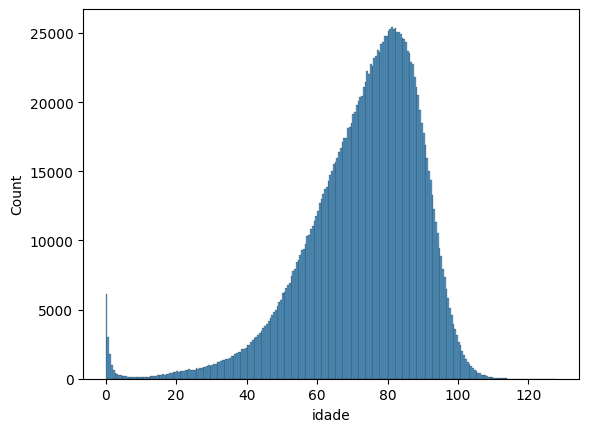

In [11]:
sns.histplot(df,x="idade",binwidth=0.5)

<Axes: xlabel='yll', ylabel='Count'>

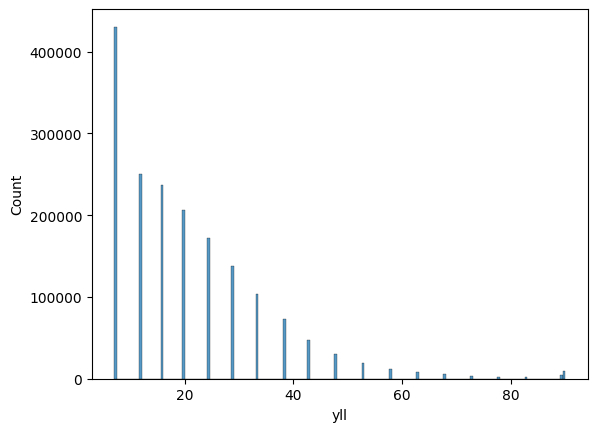

In [12]:
sns.histplot(df,x="yll",binwidth=0.5)

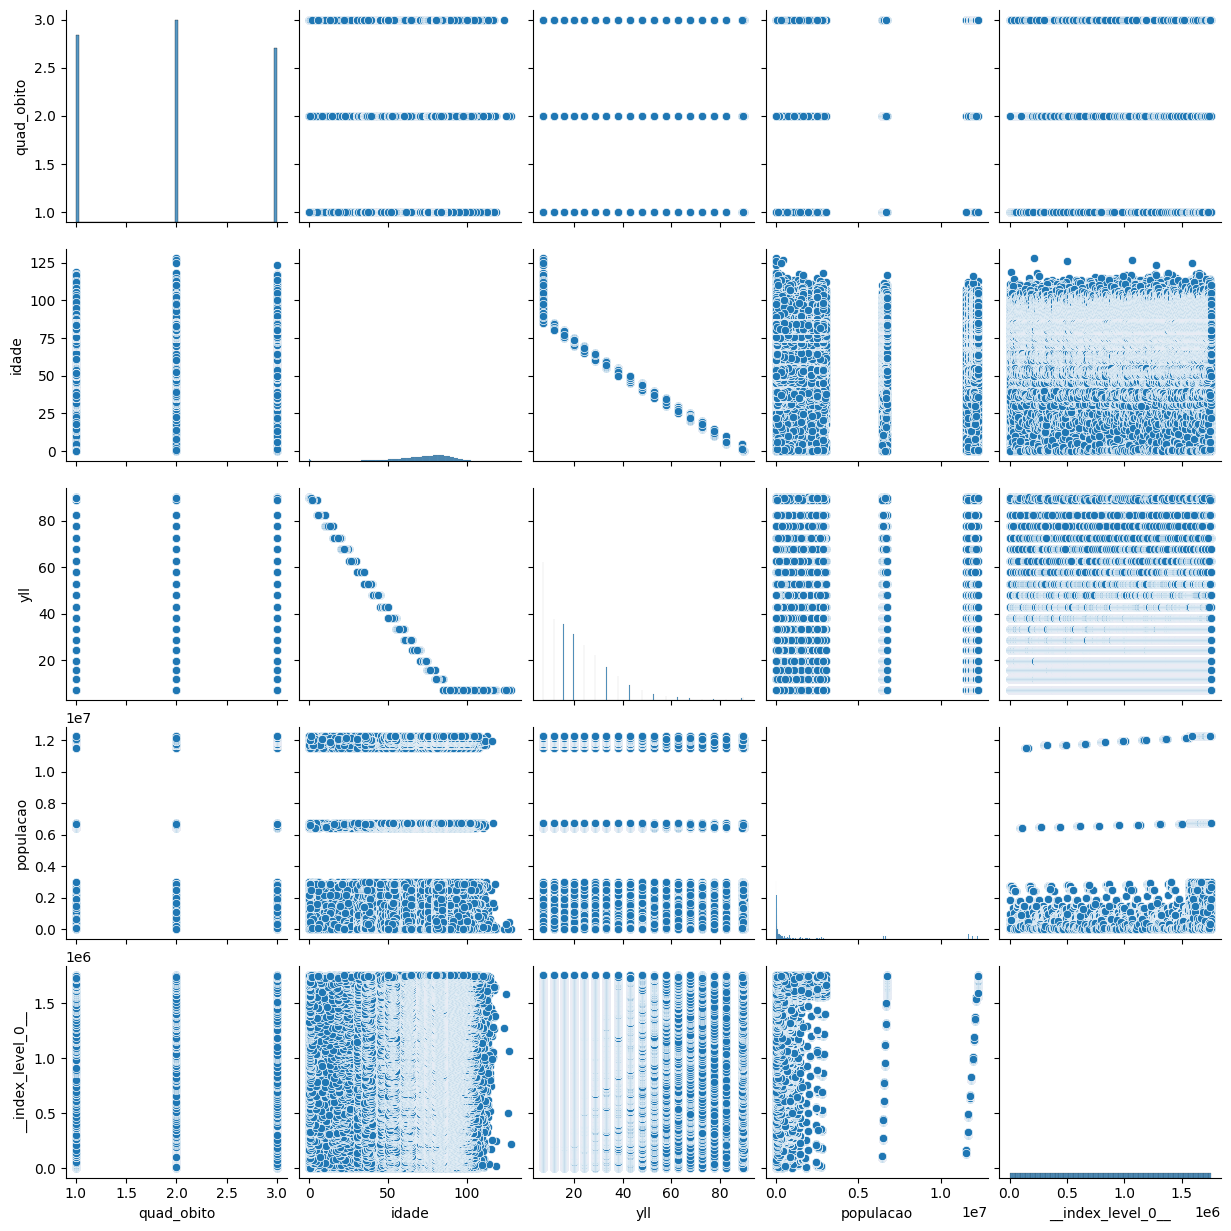

In [15]:
sns.pairplot(df)

In [15]:
# sns.pairplot(df,hue="yll")

<Axes: xlabel='yll', ylabel='cd_mun_res'>

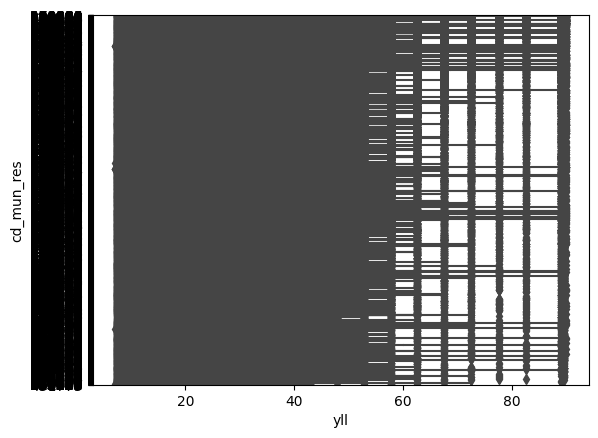

In [16]:
sns.boxplot(x="yll", y="cd_mun_res", data=df)

<Axes: xlabel='yll', ylabel='ano_obito'>

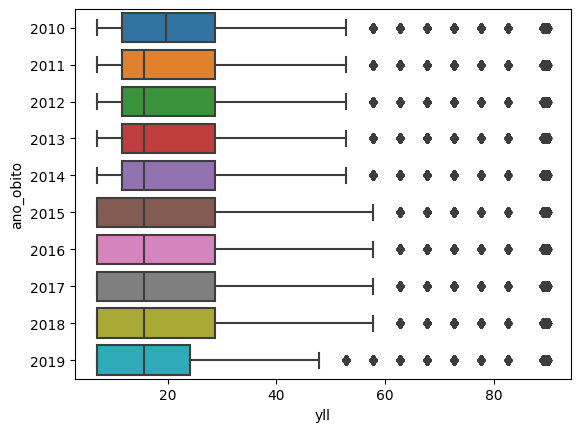

In [17]:
sns.boxplot(x="yll", y="ano_obito", data=df)

<Axes: >

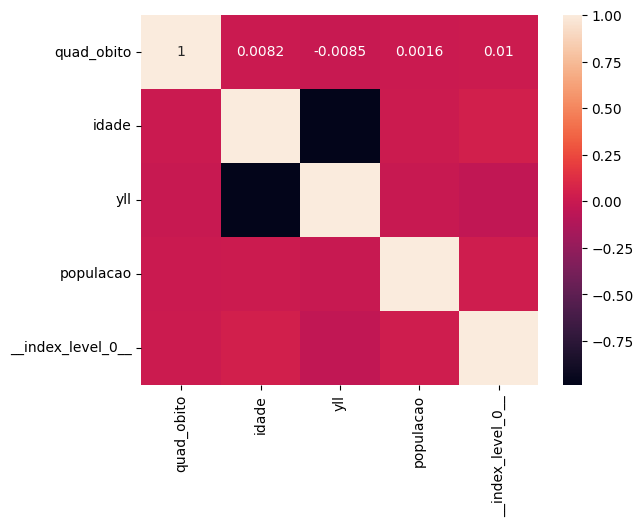

In [18]:
sns.heatmap(df.corr(),annot=True)

In [19]:
df.corr()

,quad_obito,idade,yll,populacao,__index_level_0__
quad_obito,1.000000,0.008183,-0.008476,0.001589,0.010486
idade,0.008183,1.000000,-0.983053,0.013849,0.041861
yll,-0.008476,-0.983053,1.000000,-0.012011,-0.038863
populacao,0.001589,0.013849,-0.012011,1.000000,0.028056
__index_level_0__,0.010486,0.041861,-0.038863,0.028056,1.000000


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
print(df.columns)

Index(['ano_obito', 'quad_obito', 'dt_obito', 'dt_nasc', 'idade', 'yll',
       'cid10', 'cd_mun_res', 'populacao', '__index_level_0__'],
      dtype='object')


In [28]:
df.head()

,ano_obito,quad_obito,dt_obito,dt_nasc,idade,yll,cid10,cd_mun_res,populacao,__index_level_0__
0,2010,2,2010-06-27 00:00:00+00:00,2010-03-28 00:00:00+00:00,0.25,89.55,E126,270642,10511.0,879
1,2010,1,2010-04-10 00:00:00+00:00,1993-07-10 00:00:00+00:00,16.75,72.60,N10,270915,42144.0,1862
2,2010,3,2010-09-20 00:00:00+00:00,2000-04-09 00:00:00+00:00,10.45,77.58,E41,270320,23854.0,2763
3,2010,1,2010-02-10 00:00:00+00:00,2008-12-27 00:00:00+00:00,1.12,89.07,E40,130150,16662.0,3933
4,2010,2,2010-05-10 00:00:00+00:00,2008-12-29 00:00:00+00:00,1.36,89.07,J42,130340,104059.0,4019


In [30]:
print("dimension of yll data: {}".format(df.shape))

dimension of yll data: (1754035, 10)


In [32]:
print(df.groupby('yll').size())

yll
7.05     430472
11.69    250683
15.65    237316
19.76    205976
24.12    171495
28.66    138301
33.33    103116
38.10     73008
42.94     47212
47.83     29850
52.76     18876
57.71     12379
62.66      8279
67.62      6057
72.60      3681
77.58      1788
82.58      1526
89.07      4872
89.55      8634
89.99       514
dtype: int64


<Axes: ylabel='count'>

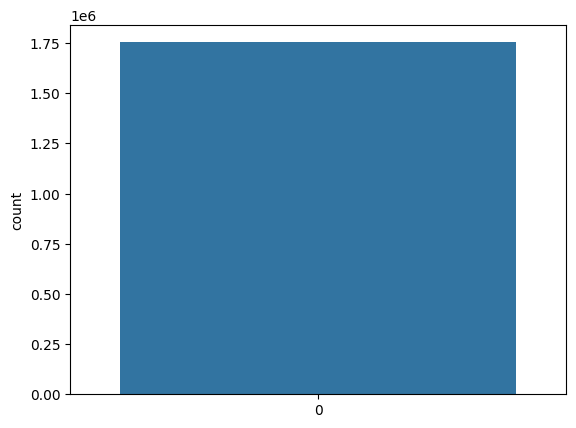

In [33]:
import seaborn as sns
sns.countplot(df['yll'],label="Count")

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1754035 entries, 0 to 1755024
Data columns (total 10 columns):
 #   Column             Dtype              
---  ------             -----              
 0   ano_obito          object             
 1   quad_obito         int64              
 2   dt_obito           datetime64[ns, UTC]
 3   dt_nasc            datetime64[ns, UTC]
 4   idade              float64            
 5   yll                float64            
 6   cid10              object             
 7   cd_mun_res         object             
 8   populacao          float64            
 9   __index_level_0__  int64              
dtypes: datetime64[ns, UTC](2), float64(3), int64(2), object(3)
memory usage: 147.2+ MB


In [35]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.loc[:, df.columns != 'yll'], df['yll'], stratify=df['yll'], random_state=66)
from sklearn.neighbors import KNeighborsClassifier
training_accuracy = []
test_accuracy = []
# try n_neighbors from 1 to 10
neighbors_settings = range(1, 11)
for n_neighbors in neighbors_settings:
    # build the model
    knn = KNeighborsClassifier(n_neighbors=n_neighbors)
    knn.fit(X_train, y_train)
    # record training set accuracy
    training_accuracy.append(knn.score(X_train, y_train))
    # record test set accuracy
    test_accuracy.append(knn.score(X_test, y_test))
plt.plot(neighbors_settings, training_accuracy, label="training accuracy")
plt.plot(neighbors_settings, test_accuracy, label="test accuracy")
plt.ylabel("Accuracy")
plt.xlabel("n_neighbors")
plt.legend()

ValueError: Unknown label type: continuous. Maybe you are trying to fit a classifier, which expects discrete classes on a regression target with continuous values.

In [36]:
knn = KNeighborsClassifier(n_neighbors=9)
knn.fit(X_train, y_train)
print('Accuracy of K-NN classifier on training set: {:.2f}'.format(knn.score(X_train, y_train)))
print('Accuracy of K-NN classifier on test set: {:.2f}'.format(knn.score(X_test, y_test)))

ValueError: Unknown label type: continuous. Maybe you are trying to fit a classifier, which expects discrete classes on a regression target with continuous values.

In [37]:
from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier(random_state=0)
tree.fit(X_train, y_train)
print("Accuracy on training set: {:.3f}".format(tree.score(X_train, y_train)))
print("Accuracy on test set: {:.3f}".format(tree.score(X_test, y_test)))

TypeError: float() argument must be a string or a real number, not 'Timestamp'

In [38]:
tree = DecisionTreeClassifier(max_depth=3, random_state=0)
tree.fit(X_train, y_train)
print("Accuracy on training set: {:.3f}".format(tree.score(X_train, y_train)))
print("Accuracy on test set: {:.3f}".format(tree.score(X_test, y_test)))

TypeError: float() argument must be a string or a real number, not 'Timestamp'

In [ ]:
print("Feature importances:\n{}".format(tree.feature_importances_))

In [ ]:
def plot_feature_importances_diabetes(model):
    plt.figure(figsize=(8,6))
    n_features = 8
    plt.barh(range(n_features), model.feature_importances_, align='center')
    plt.yticks(np.arange(n_features), diabetes_features)
    plt.xlabel("Feature importance")
    plt.ylabel("Feature")
    plt.ylim(-1, n_features)
plot_feature_importances_diabetes(tree)

In [ ]:
from sklearn.neural_network import MLPClassifier
mlp = MLPClassifier(random_state=42)
mlp.fit(X_train, y_train)
print("Accuracy on training set: {:.2f}".format(mlp.score(X_train, y_train)))
print("Accuracy on test set: {:.2f}".format(mlp.score(X_test, y_test)))

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)
mlp = MLPClassifier(random_state=0)
mlp.fit(X_train_scaled, y_train)
print("Accuracy on training set: {:.3f}".format(
    mlp.score(X_train_scaled, y_train)))
print("Accuracy on test set: {:.3f}".format(mlp.score(X_test_scaled, y_test)))

In [ ]:
mlp = MLPClassifier(max_iter=1000, alpha=1, random_state=0)
mlp.fit(X_train_scaled, y_train)
print("Accuracy on training set: {:.3f}".format(
    mlp.score(X_train_scaled, y_train)))
print("Accuracy on test set: {:.3f}".format(mlp.score(X_test_scaled, y_test)))

In [ ]:
plt.figure(figsize=(20, 5))
plt.imshow(mlp.coefs_[0], interpolation='none', cmap='viridis')
plt.yticks(range(8), diabetes_features)
plt.xlabel("Columns in weight matrix")
plt.ylabel("Input feature")
plt.colorbar()